# 🏠 Project 01 — Exploratory Data Analysis
## Nigerian Housing Market Dataset
### Week 4 Exercise · Pandas · Matplotlib · Jupyter

---

**Dataset:** `nigeria_housing.csv` — 120 properties across Lagos, Abuja, Port Harcourt, Ibadan, and Kano.  
**Your job:** Load it, clean it, explore it, and tell a story with charts.

---

### Columns

| Column | Type | Description |
|---|---|---|
| `property_id` | string | Unique property ID |
| `city` | string | One of 5 major Nigerian cities |
| `zone` | string | Neighbourhood within the city |
| `property_type` | string | Flat / Duplex / Bungalow / Detached House / Semi-Detached |
| `bedrooms` | int | Number of bedrooms |
| `bathrooms` | int | Number of bathrooms |
| `size_sqm` | int | Property size in square metres |
| `year_built` | int | Year the property was built |
| `age_years` | int | Property age (2024 − year_built) |
| `condition` | string | New / Good / Fair / Needs Renovation |
| `parking_spaces` | int | Number of parking spaces |
| `price_million_naira` | float | Listed price in ₦ million |

---


## Section 0 — Setup

Import everything you need here. Keep all imports in one place at the top — it's good practice.

**You will need:** `pandas`, `numpy`, `matplotlib.pyplot`

Also set a consistent chart style using `plt.rcParams` — things like figure size defaults, grid visibility, removing the top/right spines. You'll thank yourself later when all your charts look clean.


In [2]:
# Your imports and plot style settings go here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 6)        # default figure size
plt.rcParams["axes.grid"] = True                 # show grid
plt.rcParams["grid.alpha"] = 0.3                 # grid transparency
plt.rcParams["axes.spines.top"] = False          # remove top spine
plt.rcParams["axes.spines.right"] = False        # remove right spine
plt.rcParams["font.size"] = 12                   # default font size
plt.rcParams["axes.titlesize"] = 14              # title font size
plt.rcParams["axes.labelsize"] = 12              # axis label font size

---
## Section 1 — Load the Data

### Task 1.1 — Load and inspect

Load `nigeria_housing.csv` into a DataFrame. Then answer these questions using pandas methods — not by eyeballing:

- How many rows and columns does the dataset have?
- What is the data type of each column?
- Show the first 8 rows.


In [3]:
# Task 1.1
house_data = pd.read_csv("nigeria_housing.csv")

house_data.describe()
house_data.info()
house_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_id          120 non-null    object 
 1   city                 120 non-null    object 
 2   zone                 120 non-null    object 
 3   property_type        120 non-null    object 
 4   bedrooms             118 non-null    float64
 5   bathrooms            119 non-null    float64
 6   size_sqm             119 non-null    float64
 7   year_built           120 non-null    int64  
 8   age_years            120 non-null    int64  
 9   condition            120 non-null    object 
 10  parking_spaces       120 non-null    int64  
 11  price_million_naira  120 non-null    float64
dtypes: float64(4), int64(3), object(5)
memory usage: 11.4+ KB


,property_id,city,zone,property_type,bedrooms,bathrooms,size_sqm,year_built,age_years,condition,parking_spaces,price_million_naira
0,NG1000,Lagos,Lekki,Bungalow,2.0,2.0,139.0,2022,2,Good,0,48.10
1,NG1001,Lagos,Lekki,Flat,2.0,2.0,139.0,2022,2,Good,2,30.72
2,NG1002,Kano,Tarauni,Flat,3.0,2.0,158.0,2011,13,Good,1,7.29
3,NG1003,Ibadan,Bodija,Bungalow,4.0,3.0,255.0,2019,5,Fair,2,14.32
4,NG1004,Ibadan,Bodija,Semi-Detached,5.0,4.0,299.0,2007,17,Fair,0,26.27


### Task 1.2 — Descriptive statistics

Run `.describe()` on the full DataFrame. Before looking at the output, write down (as a comment) what you *expect* the average price and average bedroom count to be. Then check if you were right.

Also run `.info()`. This one is important — it tells you something specific that `.describe()` doesn't. What is it?


In [4]:
# Task 1.2
# My expectation for avg price: 40 ... hmmm this is waaayyy higher than I expected
# My expectation for avg bedrooms: 3 ... yaaaay! my expectation is correct!
house_data['bedrooms'].mean().round(2)
house_data['price_million_naira'].mean().round(2)

np.float64(123.13)

In [5]:
house_data.describe()

,bedrooms,bathrooms,size_sqm,year_built,age_years,parking_spaces,price_million_naira
count,118.000000,119.000000,119.000000,120.000000,120.000000,120.000000,120.000000
mean,3.008475,2.554622,194.621849,2012.608333,10.033333,1.216667,123.132333
std,1.284329,1.273574,69.408395,15.860895,5.245139,0.723940,909.784298
min,1.000000,1.000000,54.000000,1850.000000,1.000000,0.000000,-5.000000
25%,2.000000,1.000000,148.500000,2009.000000,6.000000,1.000000,15.452500
50%,3.000000,2.000000,193.000000,2014.000000,10.000000,1.000000,31.055000
75%,4.000000,4.000000,247.000000,2018.000000,15.000000,2.000000,53.122500
max,5.000000,5.000000,362.000000,2023.000000,19.000000,2.000000,9999.000000


### Task 1.3 — Missing value audit

Find every column that has missing values. Report both the **count** and the **percentage** of total rows.

> 💡 Hint: `isnull().sum()` gives counts. Think about how to get percentages from that.


In [6]:
# Task 1.3
house_data.isnull().sum()

property_id            0
city                   0
zone                   0
property_type          0
bedrooms               2
bathrooms              1
size_sqm               1
year_built             0
age_years              0
condition              0
parking_spaces         0
price_million_naira    0
dtype: int64

In [7]:
house_data.isnull().sum() / len(house_data) * 100


property_id            0.000000
city                   0.000000
zone                   0.000000
property_type          0.000000
bedrooms               1.666667
bathrooms              0.833333
size_sqm               0.833333
year_built             0.000000
age_years              0.000000
condition              0.000000
parking_spaces         0.000000
price_million_naira    0.000000
dtype: float64

---
## Section 2 — Data Cleaning

There are at least **6 problems** in this dataset. Your job is to find them all and fix them. Some are obvious, some require a bit of digging.

Work through the tasks below. By the end, save your cleaned data into a new DataFrame called `df_clean` with zero missing values.

---

### Task 2.1 — Standardise the `condition` column

Print all unique values in the `condition` column. You'll find something inconsistent. Fix it so all values follow the same capitalisation format.

> Think about: what pandas string method would normalise capitalisation across a whole column?


In [8]:
# Task 2.1
house_data['condition'] = house_data['condition'].str.lower()

house_data['condition'].value_counts() # to check the unique values in the condition column

condition
good                35
needs renovation    32
new                 29
fair                24
Name: count, dtype: int64

### Task 2.2 — Fix invalid prices

Some prices in this dataset are physically impossible. Use `.describe()` output from Section 1 and your own judgement about realistic Nigerian property prices to identify and remove bad rows.

Realistic range for this dataset: **₦1M – ₦500M**.

After removing them, print how many rows were dropped.


In [9]:
# Task 2.2
df_clean_price = house_data[(house_data['price_million_naira'] >= 1) & (house_data['price_million_naira'] <= 500)]

#invalid_house_prices = house_data[~((house_data['price_million_naira'] >= 1) & (house_data['price_million_naira'] <= 500))]

print(f"Rows dropped: {len(house_data) - len(df_clean_price)}")


Rows dropped: 2


In [10]:
#Method 2
#df_clean = house_data[house_data['price_million_naira'].between(1, 500)]

#print(f"Rows dropped: {len(house_data) - len(df_clean)}")

In [11]:
df_clean_price.describe()

,bedrooms,bathrooms,size_sqm,year_built,age_years,parking_spaces,price_million_naira
count,116.000000,117.000000,117.000000,118.000000,118.000000,118.000000,118.000000
mean,3.008621,2.555556,194.811966,2012.567797,10.050847,1.211864,40.524407
std,1.288718,1.269296,69.955150,15.966567,5.208224,0.726209,34.931992
min,1.000000,1.000000,54.000000,1850.000000,1.000000,0.000000,5.070000
25%,2.000000,1.000000,148.000000,2009.000000,6.000000,1.000000,15.640000
50%,3.000000,2.000000,193.000000,2014.000000,10.000000,1.000000,31.055000
75%,4.000000,4.000000,247.000000,2018.000000,15.000000,2.000000,51.975000
max,5.000000,5.000000,362.000000,2023.000000,19.000000,2.000000,176.920000


### Task 2.3 — Fix impossible `year_built` values

Nigeria's modern housing stock largely dates from post-independence (1960 onwards). Any `year_built` before 1960 is a data entry error.

Find those rows, remove them, and recalculate `age_years` for consistency.


In [12]:
# Task 2.3
# Don't forget to recalculate age_years after fixing year_built
df_clean = df_clean_price[df_clean_price['year_built'] >= 1960]

df_clean.loc[:, 'age_years'] = 2024 - df_clean['year_built']

df_clean.describe()

,bedrooms,bathrooms,size_sqm,year_built,age_years,parking_spaces,price_million_naira
count,115.000000,116.000000,116.000000,117.000000,117.000000,117.000000,117.000000
mean,3.026087,2.568966,195.767241,2013.957265,10.042735,1.213675,40.827436
std,1.280494,1.266451,69.487986,5.229876,5.229876,0.729065,34.926128
min,1.000000,1.000000,54.000000,2005.000000,1.000000,0.000000,5.760000
25%,2.000000,1.000000,148.750000,2009.000000,6.000000,1.000000,16.000000
50%,3.000000,2.000000,193.500000,2014.000000,10.000000,1.000000,31.390000
75%,4.000000,4.000000,247.750000,2018.000000,15.000000,2.000000,52.720000
max,5.000000,5.000000,362.000000,2023.000000,19.000000,2.000000,176.920000


In [13]:
df_clean.head()

,property_id,city,zone,property_type,bedrooms,bathrooms,size_sqm,year_built,age_years,condition,parking_spaces,price_million_naira
0,NG1000,Lagos,Lekki,Bungalow,2.0,2.0,139.0,2022,2,good,0,48.10
1,NG1001,Lagos,Lekki,Flat,2.0,2.0,139.0,2022,2,good,2,30.72
2,NG1002,Kano,Tarauni,Flat,3.0,2.0,158.0,2011,13,good,1,7.29
3,NG1003,Ibadan,Bodija,Bungalow,4.0,3.0,255.0,2019,5,fair,2,14.32
4,NG1004,Ibadan,Bodija,Semi-Detached,5.0,4.0,299.0,2007,17,fair,0,26.27


### Task 2.4 — Handle missing numeric values

Three columns have missing values in numeric fields. Fill each one with the **median** of that column (not the mean).

Before you do this, think about: *why median and not mean?* Write your answer as a comment.


In [14]:
# Task 2.4
# Why median? (your answer here)
median_bathrooms = house_data['bathrooms'].median()
median_bedrooms = house_data['bedrooms'].median()
median_size_sqm = house_data['size_sqm'].median()

house_data.fillna({
    'bathrooms': median_bathrooms,
    'bedrooms': median_bedrooms,
    'size_sqm': median_size_sqm
}, inplace=True)

house_data.isna().any()


property_id            False
city                   False
zone                   False
property_type          False
bedrooms               False
bathrooms              False
size_sqm               False
year_built             False
age_years              False
condition              False
parking_spaces         False
price_million_naira    False
dtype: bool

### Task 2.5 — Create a derived feature: `price_per_sqm`

Add a new column to your clean DataFrame:

```
price_per_sqm = (price_million_naira × 1000) / size_sqm
```

This gives price in ₦ thousand per square metre. It lets you compare a small flat and a large house on equal footing.

Round it to 2 decimal places.


In [15]:
# Task 2.5
df_clean.loc[:, 'price_per_sqm'] = ((df_clean['price_million_naira'] * 1000) / df_clean['size_sqm']).round(2)

df_clean.head()

/var/folders/31/b5p6jrzx55s8qw7nw0f03nfw0000gn/T/ipykernel_1522/163486651.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean.loc[:, 'price_per_sqm'] = ((df_clean['price_million_naira'] * 1000) / df_clean['size_sqm']).round(2)


,property_id,city,zone,property_type,bedrooms,bathrooms,size_sqm,year_built,age_years,condition,parking_spaces,price_million_naira,price_per_sqm
0,NG1000,Lagos,Lekki,Bungalow,2.0,2.0,139.0,2022,2,good,0,48.10,346.04
1,NG1001,Lagos,Lekki,Flat,2.0,2.0,139.0,2022,2,good,2,30.72,221.01
2,NG1002,Kano,Tarauni,Flat,3.0,2.0,158.0,2011,13,good,1,7.29,46.14
3,NG1003,Ibadan,Bodija,Bungalow,4.0,3.0,255.0,2019,5,fair,2,14.32,56.16
4,NG1004,Ibadan,Bodija,Semi-Detached,5.0,4.0,299.0,2007,17,fair,0,26.27,87.86


### Task 2.6 — Final check

Confirm `df_clean` is ready:
- Zero missing values
- No invalid prices or years
- `price_per_sqm` column exists
- Shape makes sense given what you removed

Print a summary that confirms all of this.


In [16]:
# Task 2.6
df_clean.describe()

,bedrooms,bathrooms,size_sqm,year_built,age_years,parking_spaces,price_million_naira,price_per_sqm
count,115.000000,116.000000,116.000000,117.000000,117.000000,117.000000,117.000000,116.000000
mean,3.026087,2.568966,195.767241,2013.957265,10.042735,1.213675,40.827436,223.287586
std,1.280494,1.266451,69.487986,5.229876,5.229876,0.729065,34.926128,180.714004
min,1.000000,1.000000,54.000000,2005.000000,1.000000,0.000000,5.760000,33.920000
25%,2.000000,1.000000,148.750000,2009.000000,6.000000,1.000000,16.000000,84.575000
50%,3.000000,2.000000,193.500000,2014.000000,10.000000,1.000000,31.390000,161.760000
75%,4.000000,4.000000,247.750000,2018.000000,15.000000,2.000000,52.720000,306.345000
max,5.000000,5.000000,362.000000,2023.000000,19.000000,2.000000,176.920000,980.340000


---
## Section 3 — Exploratory Analysis

Before plotting anything, compute summary tables. Charts should confirm numbers you already know — not surprise you.

### Task 3.1 — City price summary

Group by city and compute: count, mean, median, std, min, max for `price_million_naira`. Sort by median price descending.

Which city is most expensive? By how much is it ahead of the second?


In [17]:
# Task 3.1
city_price_summary = df_clean.groupby('city')['price_million_naira'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).round(2).sort_values(by='median', ascending=False)

print(f"Most expensive city: {city_price_summary.index[0]} with median price of {city_price_summary.iloc[0]['median']} million Naira")

print(f"It is ahead of the second most expensive city, {city_price_summary.index[1]}, by {city_price_summary.iloc[0]['median'] - city_price_summary.iloc[1]['median']:2f} million Naira in median price.")

#

Most expensive city: Lagos with median price of 64.08 million Naira
It is ahead of the second most expensive city, Abuja, by 5.540000 million Naira in median price.


### Task 3.2 — Property type and condition counts

How many properties of each `property_type` are in the dataset? And each `condition`?

Are any categories so small they might skew a chart?


In [ ]:
# Task 3.2
df_clean['property_type'].value_counts()


property_type
Flat              26
Bungalow          24
Detached House    24
Semi-Detached     23
Duplex            20
Name: count, dtype: int64

In [30]:
df_clean['condition'].value_counts()

condition
good                34
needs renovation    31
new                 28
fair                24
Name: count, dtype: int64

### Task 3.3 — Correlation check

Compute the correlation between all numeric columns. Then extract just the row (or column) for `price_million_naira` and sort it.

Which feature has the strongest positive correlation with price? Which has the weakest?


In [ ]:
# Task 3.3
numeric_cols = ['bathrooms', 'bedrooms', 'size_sqm', 'age_years', 'price_million_naira', 'price_per_sqm']
df_clean[numeric_cols].corr().round(2)

,bathrooms,bedrooms,size_sqm,age_years,price_million_naira,price_per_sqm
bathrooms,1.000000,0.924059,0.817301,0.151838,0.370006,-0.019930
bedrooms,0.924059,1.000000,0.884540,0.233874,0.332491,-0.086607
size_sqm,0.817301,0.884540,1.000000,0.189072,0.264041,-0.221235
age_years,0.151838,0.233874,0.189072,1.000000,-0.043134,-0.148476
price_million_naira,0.370006,0.332491,0.264041,-0.043134,1.000000,0.812301
price_per_sqm,-0.019930,-0.086607,-0.221235,-0.148476,0.812301,1.000000


In [43]:
price_corr = df_clean[numeric_cols].corr()['price_million_naira'].sort_values(ascending=False).round(2)

print(f"The strongest positive correlation with price_million_naira is {price_corr.index[1]} with a correlation of {price_corr.iloc[1]}")

The strongest positive correlation with price_million_naira is price_per_sqm with a correlation of 0.81


---
## Section 4 — Visualisations

Produce **6 charts** using **matplotlib only** (no seaborn). 

For every chart:
- Give it a clear title and labelled axes
- Include units in axis labels (e.g. "Price (₦ million)")
- Remove the top and right spines for a cleaner look
- Add a grid on the relevant axis

After each chart, fill in the **📝 Insight** cell with 3–5 sentences of your own analysis. This narrative is as important as the chart itself.

---

### 📊 Chart 1 — Median Property Price by City (Bar Chart)

Use `ax.bar()`. Sort cities from highest to lowest median price. Annotate each bar with the actual value.

> Things to look for: How large is the gap between the most and least expensive city? Does the ranking match your intuition about Nigeria's property market?


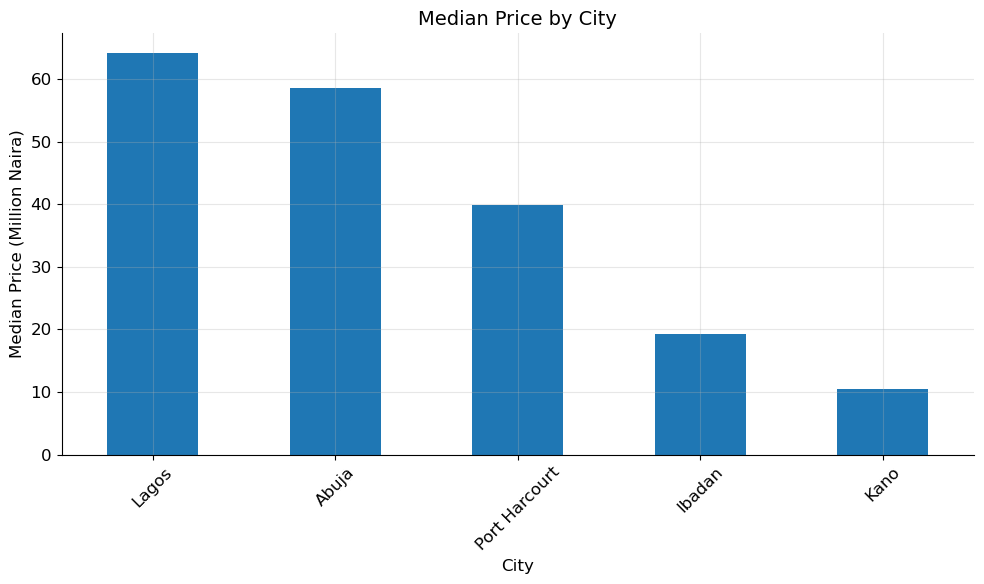

In [45]:
# Chart 1 — Median price by city
df_clean.groupby('city')['price_million_naira'].median().sort_values(ascending=False).plot(kind='bar')
plt.title("Median Price by City")
plt.xlabel("City")
plt.ylabel("Median Price (Million Naira)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 📝 Insight — Chart 1

*Write 3–5 sentences here. What does this chart tell you? What surprised you?*


- Lagos is the most expensive city. I expected Abuja to be the most expected tho. Is this due to the population in Lagos? Should population affect the house prices at all?

- Kano is the least espensive. That's very much expected. 

- Also, maybe because is kinda old, I think the most recent date was 2024. But currently, in 2026, houses in Ibadan are getting as expensive as those in Lagos. 

- So this shows the relevancy of using a good dataset for analysis.

---
### 📊 Chart 2 — Price Distribution by City (Box Plot)

Use `ax.boxplot()`. A bar chart only shows the median — a box plot shows the full spread: median, IQR, and outliers.

> Things to look for: Which city has the widest spread? Are there visible outliers? Does a wide box mean something different from a narrow one?


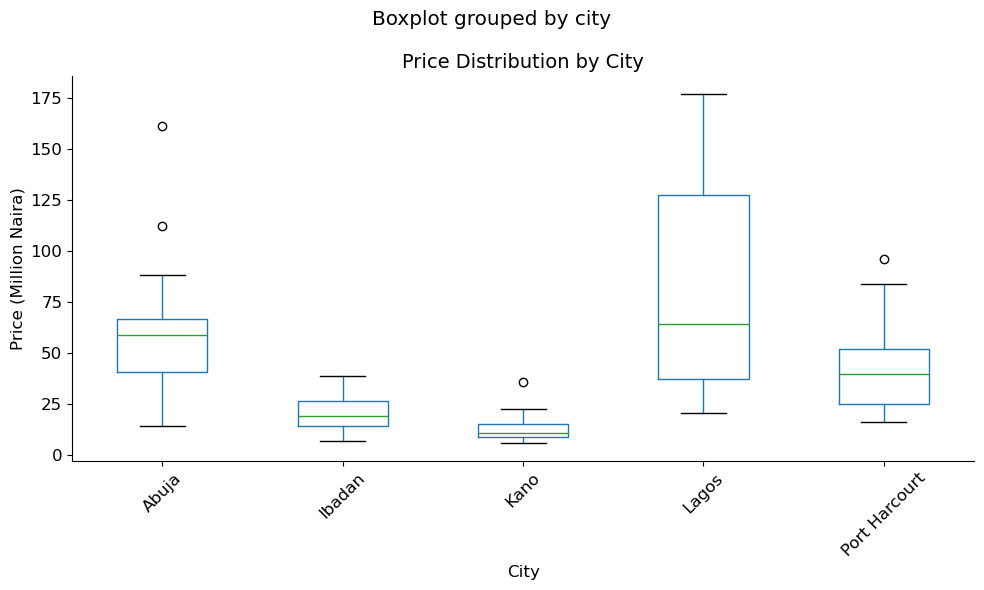

In [46]:
# Chart 2 — Price distribution by city (box plot)
# Hint: ax.boxplot() takes a list of arrays. Use a list comprehension to
# extract price values for each city in a consistent order.

df_clean.boxplot(column='price_million_naira', by='city', grid=False)
plt.title("Price Distribution by City")
plt.xlabel("City")
plt.ylabel("Price (Million Naira)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 📝 Insight — Chart 2

*Write 3–5 sentences here. What does the spread tell you that the bar chart didn't?*


---
### 📊 Chart 3 — Bedrooms vs. Price (Scatter Plot, coloured by city)

Use `ax.scatter()`. Plot one city at a time in a loop so you can assign each a distinct colour and add a legend. Add an overall trend line using `numpy.polyfit`.

> Things to look for: Is the relationship linear? Do all cities follow the same trend? What explains the wide vertical scatter at any given bedroom count?


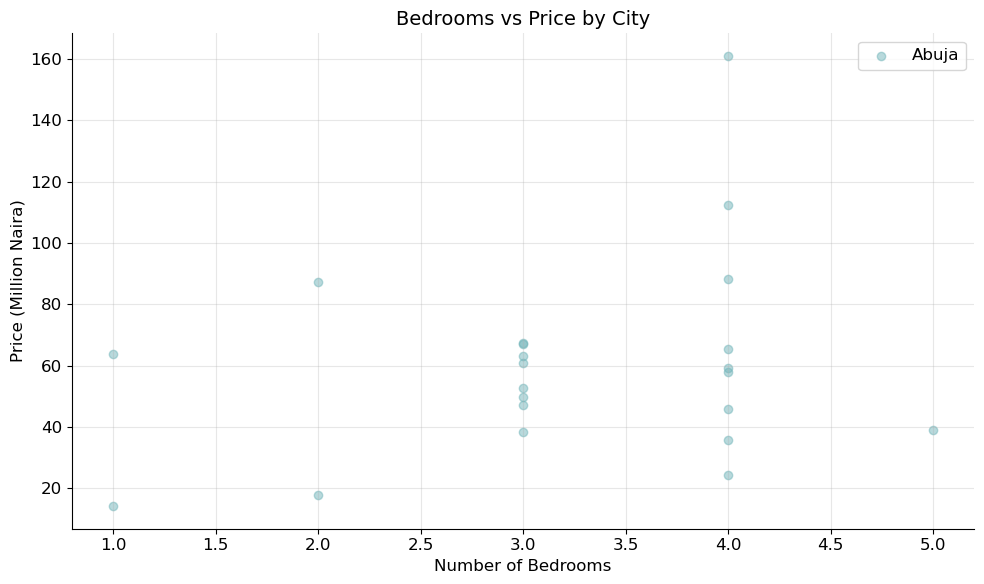

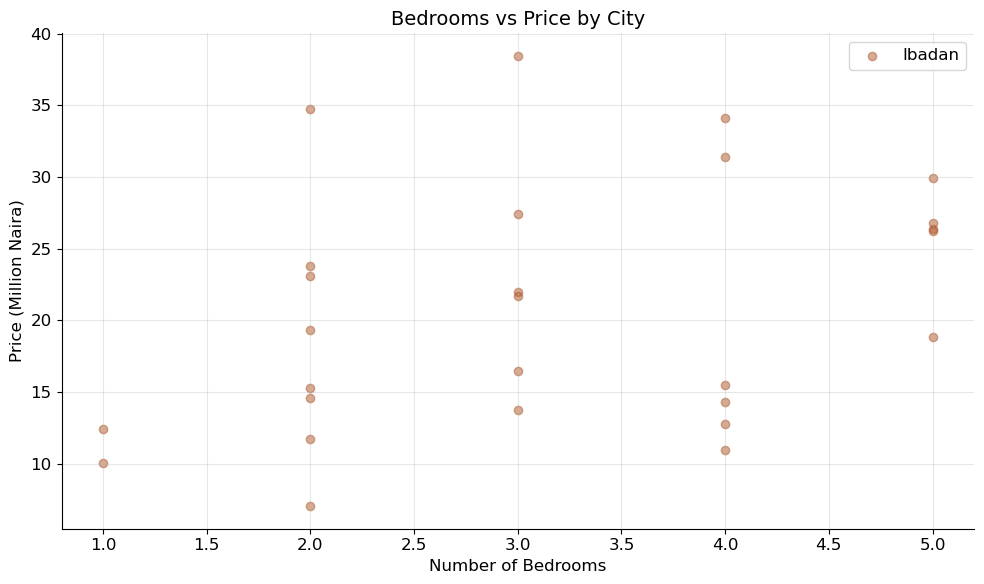

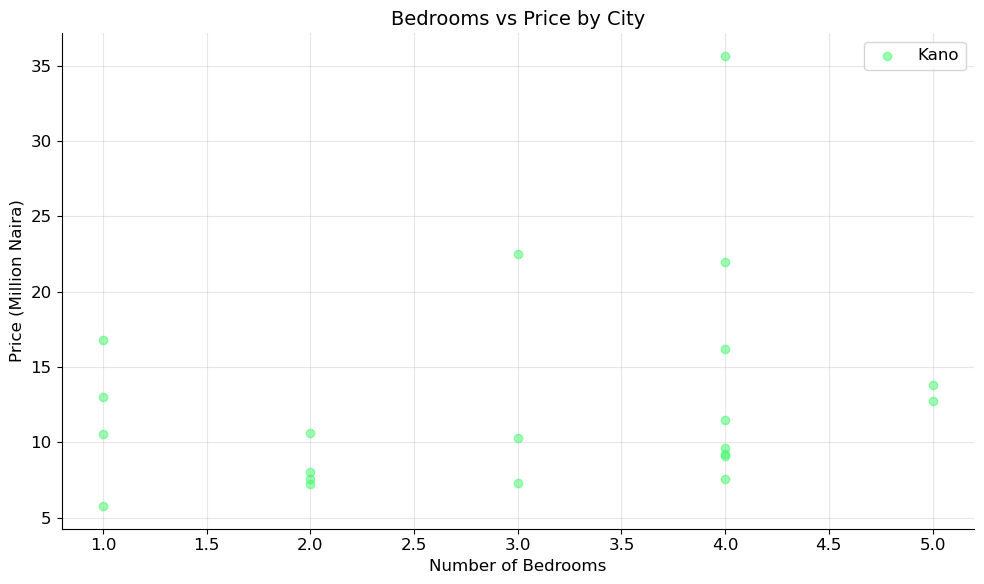

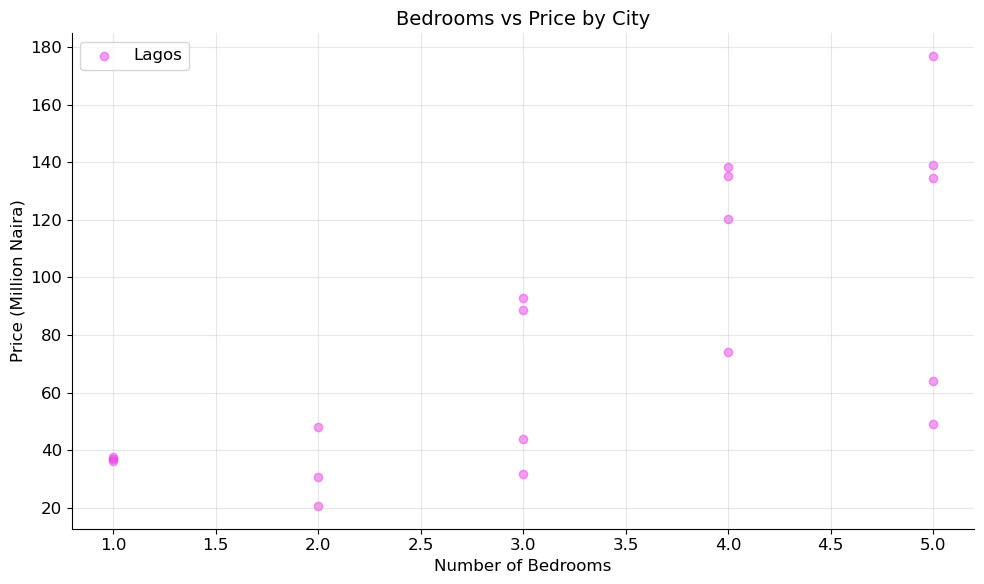

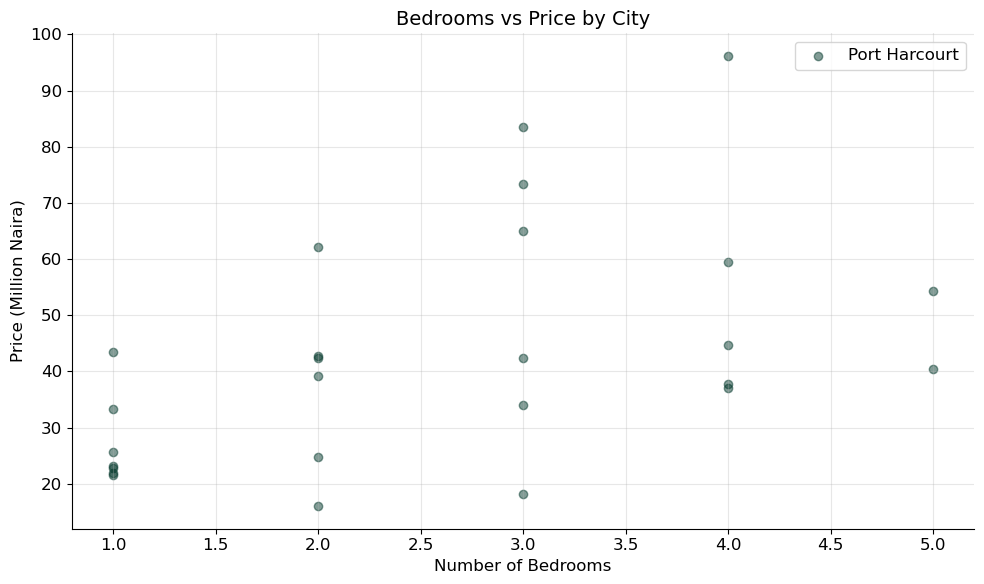

In [61]:
# Chart 3 — Bedrooms vs price scatter
# Hint: loop over df_clean.groupby('city') and call ax.scatter() once per city
# For the trend line: np.polyfit(x, y, deg=1) then np.poly1d()

city_groups = df_clean.groupby('city')
for city, city_df in city_groups:
    plt.scatter(city_df['bedrooms'], city_df['price_million_naira'], label=city, alpha=0.5, color=np.random.rand(3,))  # random color for each city
    plt.title("Bedrooms vs Price by City")
    plt.xlabel("Number of Bedrooms")
    plt.ylabel("Price (Million Naira)")
    plt.legend()
    plt.tight_layout()
    plt.show()


### 📝 Insight — Chart 3

*Write 3–5 sentences here.*


I am still very much terrible at ready scatterplot, so I can't get any insight from the plots for now. 🥲

---
### 📊 Chart 4 — Average Price per sqm by City (Horizontal Bar)

Use `ax.barh()`. Sort from lowest to highest (so the longest bar is at the top). Annotate each bar.

> Things to look for: Does this ranking match Chart 1? If a city moves up or down in this chart vs Chart 1, what does that mean?


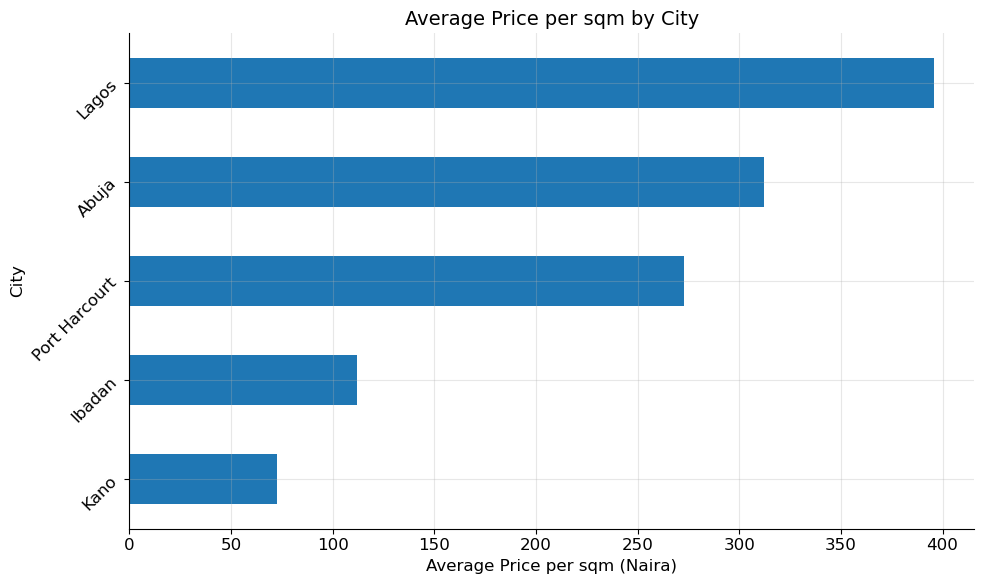

In [63]:
# Chart 4 — Price per sqm by city (horizontal bar)
df_clean.groupby('city')['price_per_sqm'].mean().sort_values().plot(kind='barh')
plt.title("Average Price per sqm by City")
plt.xlabel("Average Price per sqm (Naira)")
plt.ylabel("City")
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

### 📝 Insight — Chart 4

*Write 3–5 sentences here. Compare directly to Chart 1 — same story or different?*


The same behaviour as chart 1.

---
### 📊 Chart 5 — Property Condition vs. Average Price (Bar Chart)

Use `ax.bar()`. Order the conditions logically: New → Good → Fair → Needs Renovation. 

> Things to look for: How steep is the price drop from "New" to "Needs Renovation"? Is this gradient what you expected?


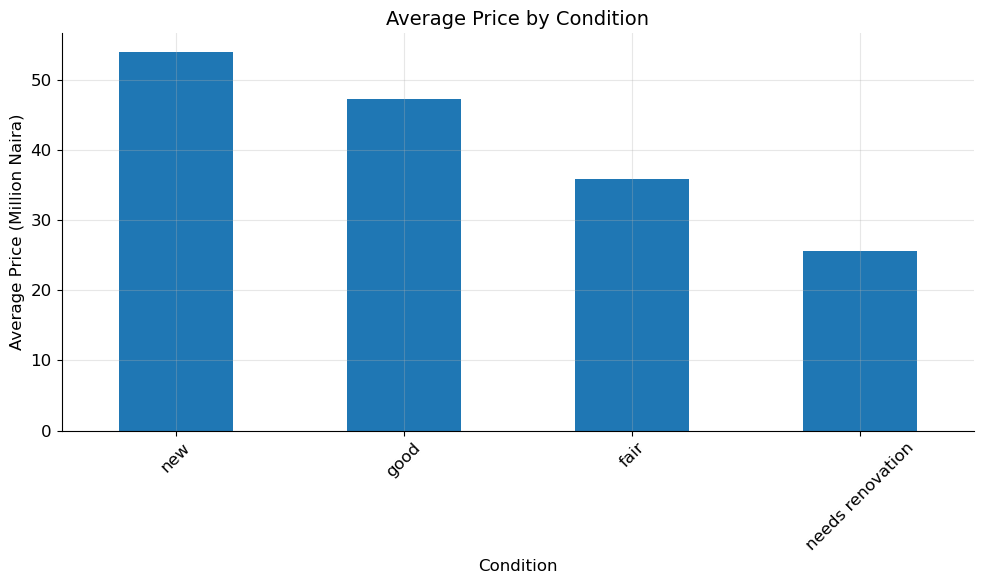

In [67]:
# Chart 5 — Condition vs average price
cond_order = ['new', 'good', 'fair', 'needs renovation']

df_clean.groupby('condition')['price_million_naira'].mean().reindex(cond_order).plot(kind='bar')
plt.title("Average Price by Condition")
plt.xlabel("Condition")
plt.ylabel("Average Price (Million Naira)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 📝 Insight — Chart 5

*Write 3–5 sentences here. What does this mean for someone buying a property that needs renovation?*


The price drop from "New" to "Needs renovation" is very much expected. Someone will spend less when buying a property tht needs renovation and they will eventually spend more to renovate the property if they want it to be as good as new.

---
### 📊 Chart 6 — Correlation Heatmap (Matplotlib only)

Use `ax.imshow()` to render the correlation matrix as a colour grid. Add text annotations in each cell with `ax.text()`. Label axes with column names.

This one is harder to build without seaborn — that's intentional. Working through it will teach you how heatmaps actually work under the hood.

> Things to look for: What is the strongest predictor of price? Is there multicollinearity between any pair of features?

> 💡 Hint: `corr_matrix.values` gives you the raw numpy array. Use `cmap='RdYlGn'` for a sensible diverging colour scale.


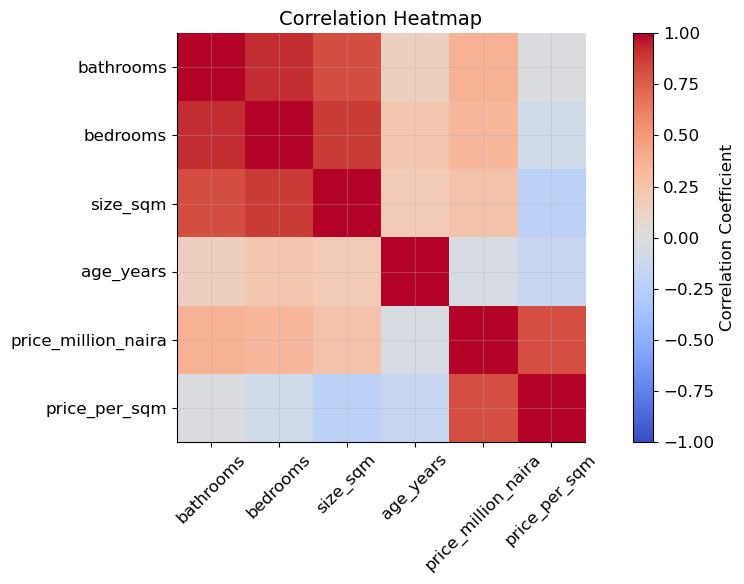

In [71]:
# Chart 6 — Correlation heatmap using ax.imshow()
# Hint: use ax.set_xticks / ax.set_yticks for labels
# Use ax.text() in a nested loop to annotate each cell
numeric_cols = ['bathrooms', 'bedrooms', 'size_sqm', 'age_years', 'price_million_naira', 'price_per_sqm']
corr_matrix = df_clean[numeric_cols].corr().round(2)


im = plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)

plt.colorbar(im, label='Correlation Coefficient')
plt.xticks(ticks=np.arange(len(numeric_cols)), labels=numeric_cols, rotation=45)
plt.yticks(ticks=np.arange(len(numeric_cols)), labels=numeric_cols)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### 📝 Insight — Chart 6

*Write 3–5 sentences here. Which 3 features would you use to build a price prediction model based on this heatmap?*


Hmmmm to build a price prediction models based on this heatmap, I would use the 3 following features:
- number of bathrooms
- number of bedrooms
- size per sqm

---
## Section 6 — Extension Challenges (optional)


**Zone-level deep dive:** Which zone within Lagos commands the highest average price? Use `.groupby(["city","zone"])`.


In [78]:
# Which zone within Lagos commands the highest average price? Use df_clean.groupby(["city","zone"]) to find out.

zone_prices = df_clean.groupby(['city', 'zone'])['price_million_naira'].mean().sort_values(ascending=False)

print(f"The zone with the highest average price in Lagos is {zone_prices.index[0][1]} with an average price of {zone_prices.iloc[0]:.2f} million Naira")

The zone with the highest average price in Lagos is Surulere with an average price of 150.42 million Naira


---
# Final Note ✨

This exercise was designed with the assistance of Claude (Anthropic) as part of a structured ML learning roadmap. If you'd like to work through it yourself, feel free to download the blank notebook. 